# Unsupervised Learning - Clustering with K-means

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "Employees_income.csv"))
df_copy = df.copy()

In [4]:
df.shape

(22, 3)

In [5]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [6]:
df.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


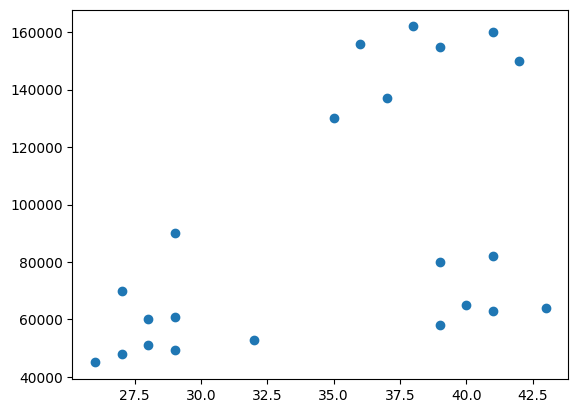

In [7]:
plt.scatter(df["Age"], df["Income($)"])

In [8]:
df.columns

Index(['Name', 'Age', 'Income($)'], dtype='object')

### Escalar dataset

In [9]:
scalar = StandardScaler()

In [10]:
df_scaled = df.copy()
df_scaled[["Age", "Income($)"]] = scalar.fit_transform(df[["Age", "Income($)"]])
df_scaled.head()

,Name,Age,Income($)
0,Rob,-1.356055,-0.480684
1,Michael,-1.009157,-0.010159
2,Mohan,-1.009157,-0.692421
3,Ismail,-1.182606,-0.715947
4,Kory,1.245679,1.401417


### K-means model

In [11]:
km_model = KMeans(n_clusters = 3, random_state = 100)

In [12]:
km_model.fit(df_scaled[["Age", "Income($)"]])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,100
,copy_x,True
,algorithm,'lloyd'


In [13]:
km_model.inertia_

3.889308657130143

In [14]:
df_scaled["Label"] = km_model.labels_
df_scaled.head()

,Name,Age,Income($),Label
0,Rob,-1.356055,-0.480684,0
1,Michael,-1.009157,-0.010159,0
2,Mohan,-1.009157,-0.692421,0
3,Ismail,-1.182606,-0.715947,0
4,Kory,1.245679,1.401417,1


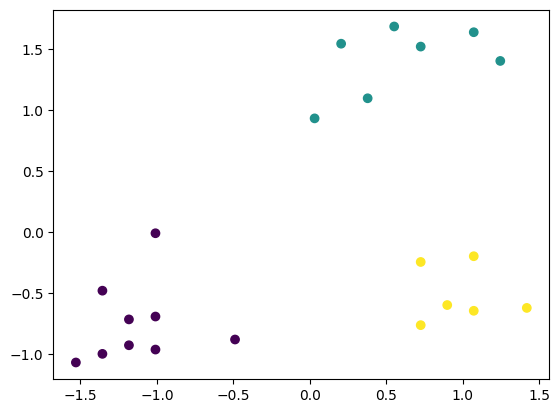

In [15]:
plt.scatter(df_scaled["Age"], df_scaled["Income($)"], c = df_scaled["Label"])